In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DL-Project/data/train.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(159571, 8)
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [13]:
import re

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

def simple_tokenize(text):
    text = text.lower().replace('\n', ' ')
    return re.findall(r"[a-z0-9']+|[^\sa-z0-9']", text)

df['n_chars'] = df['comment_text'].str.len()
df['n_tokens'] = df['comment_text'].apply(lambda t: len(simple_tokenize(t)))
print(simple_tokenize("You are SO dumb!!\nGo away."))

['you', 'are', 'so', 'dumb', '!', '!', 'go', 'away', '.']


In [14]:
for col in ['n_chars', 'n_tokens']:
    s = df[col]
    print(f"{col}: mean={s.mean():.1f}, median={s.median():.0f}, "
          f"95th={s.quantile(0.95):.0f}, 99th={s.quantile(0.99):.0f}, max={s.max()}")

over = (df['n_tokens'] > 128).mean() * 100
print(f"\nComments longer than 128 tokens: {over:.1f}%")

n_chars: mean=394.1, median=205, 95th=1355, 99th=3444, max=5000
n_tokens: mean=83.0, median=44, 95th=279, 99th=707, max=4948

Comments longer than 128 tokens: 16.5%


In [15]:
df['any_toxic'] = df[label_cols].max(axis=1)
print(df.groupby('any_toxic')['n_tokens'].describe(percentiles=[0.5, 0.95]).round(1))

              count  mean    std  min   50%    95%     max
any_toxic                                                 
0          143346.0  84.8  121.4  2.0  46.0  283.0  3042.0
1           16225.0  67.3  154.7  2.0  29.0  219.0  4948.0


In [16]:
import os
results_dir = '/content/drive/MyDrive/DL-Project/results'
os.makedirs(results_dir, exist_ok=True)

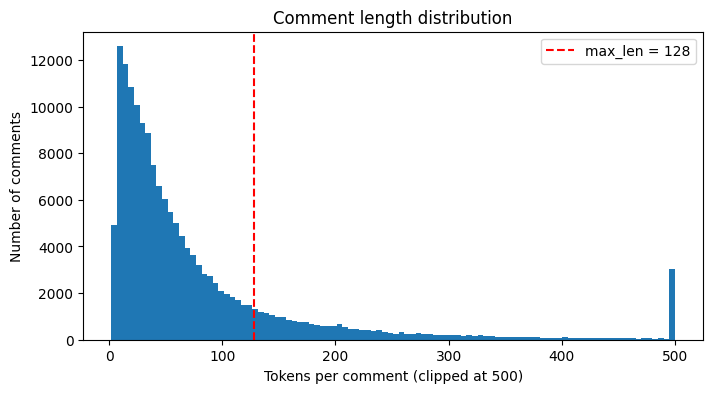

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df['n_tokens'].clip(upper=500), bins=100)
plt.axvline(128, color='red', linestyle='--', label='max_len = 128')
plt.xlabel('Tokens per comment (clipped at 500)')
plt.ylabel('Number of comments')
plt.title('Comment length distribution')
plt.legend()
plt.savefig(f'{results_dir}/comment_length_hist.png', dpi=150, bbox_inches='tight')
plt.show()

⚠️ Content warning: the word clouds below contain offensive and hateful language taken directly from the dataset. They are shown only to analyse the data.

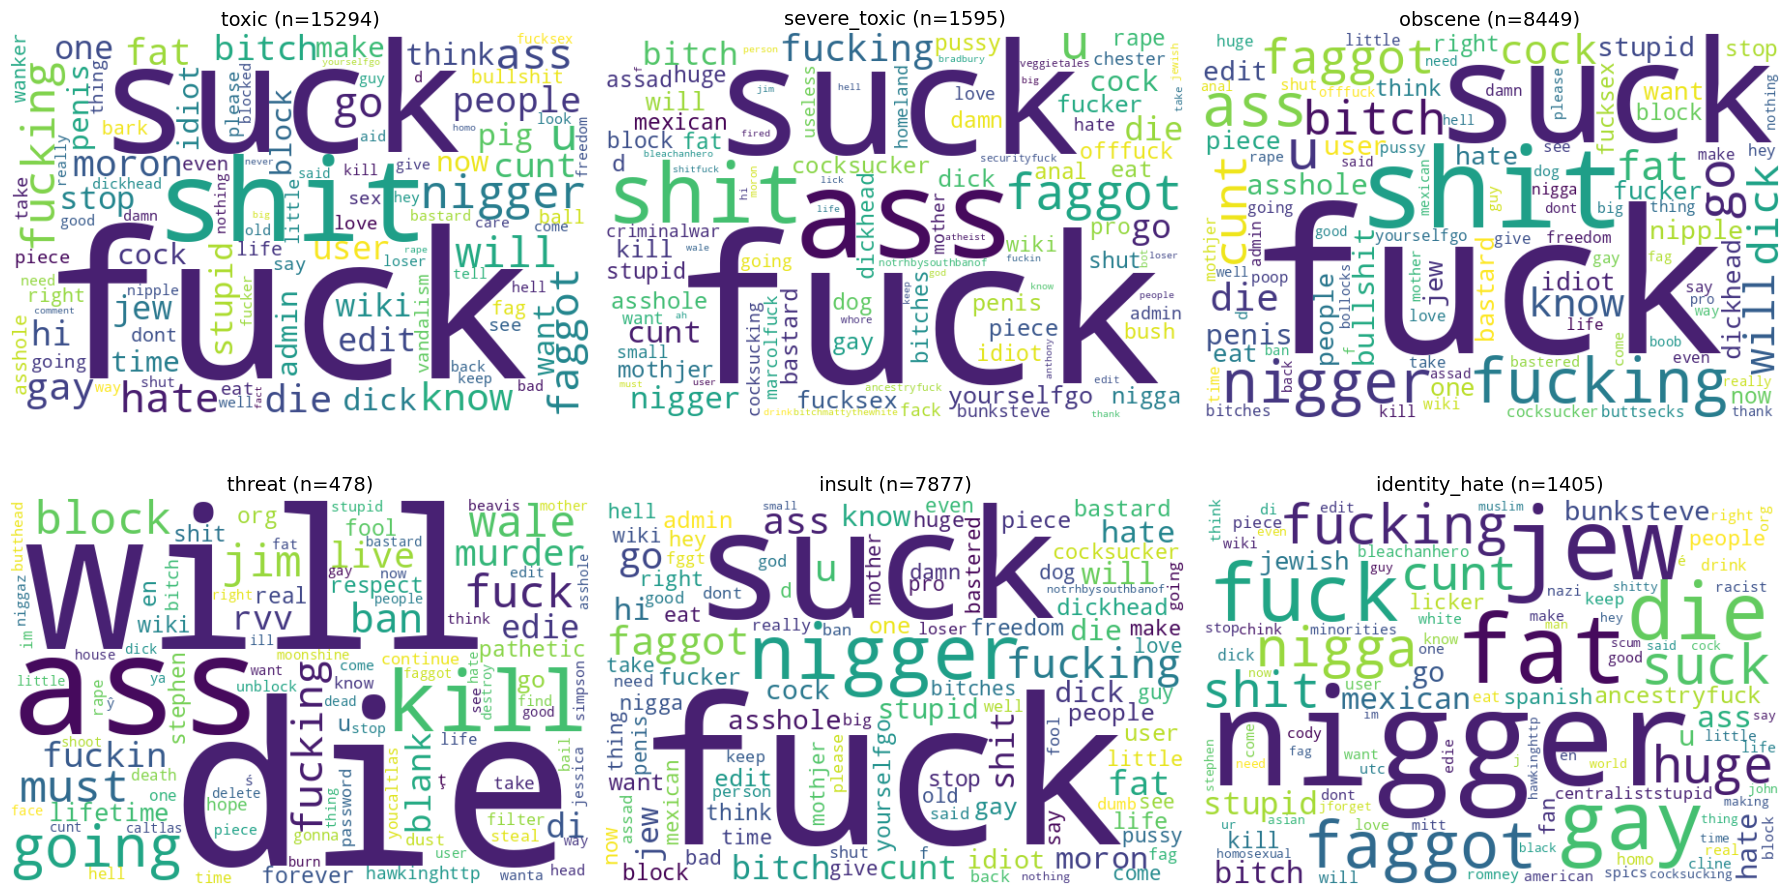

In [18]:
from wordcloud import WordCloud, STOPWORDS

stop_words = STOPWORDS | {'wikipedia', 'article', 'page', 'talk'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, label in zip(axes.flat, label_cols):
    texts = df.loc[df[label] == 1, 'comment_text']
    words = ' '.join(w for t in texts for w in simple_tokenize(t) if w.isalpha())
    wc = WordCloud(width=600, height=400, background_color='white',
                   stopwords=stop_words, max_words=100,
                   collocations=False, random_state=42).generate(words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{label} (n={len(texts)})", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{results_dir}/wordclouds_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from collections import Counter

counter = Counter()
for t in df['comment_text']:
    counter.update(simple_tokenize(t))

total_tokens = sum(counter.values())
vocab_all = len(counter)
vocab_min2 = sum(1 for c in counter.values() if c >= 2)
covered = sum(c for c in counter.values() if c >= 2) / total_tokens * 100

print(f"Total tokens in dataset:      {total_tokens:,}")
print(f"Unique tokens (full vocab):   {vocab_all:,}")
print(f"Vocab with min_freq=2:        {vocab_min2:,}")
print(f"Token coverage with min_freq=2: {covered:.2f}%")
print("\nTop 20 tokens:", counter.most_common(20))

Total tokens in dataset:      13,250,066
Unique tokens (full vocab):   201,353
Vocab with min_freq=2:        94,883
Token coverage with min_freq=2: 99.20%

Top 20 tokens: [('.', 680368), ('the', 496866), (',', 474958), ('"', 392552), ('to', 297493), ('of', 225057), ('and', 224262), ('a', 216034), ('you', 206236), ('i', 205002), ('is', 176469), ('that', 154664), ('in', 145717), ('it', 130674), ('!', 105576), ('for', 102976), ('-', 102382), ('this', 97631), (':', 95215), ('not', 93790)]
